# Reinforcement Learning

## Introduction

In supervised learning, we train models on labeled data: given inputs $X$ and known outputs $y$, the model learns a mapping $f: X \to y$. In unsupervised learning, we discover structure in unlabeled data. **Reinforcement learning (RL)** is a fundamentally different paradigm: an **agent** learns to make decisions by interacting with an **environment**, receiving **rewards** as feedback, and improving its behavior over time.

The key distinction is that nobody tells the agent what the correct action is. Instead, the agent must discover which actions yield the most reward through trial and error. This is closer to how humans and animals actually learn: a child touches a hot stove (action), feels pain (negative reward), and learns not to do it again.

In this lecture, we will cover:

* How RL differs from other machine learning paradigms
* The agent-environment interaction loop
* Markov decision processes (MDPs)
* Value functions and the Bellman equation
* Q-learning: learning from experience
* Exploration vs. exploitation
* Policy gradient methods
* Deep reinforcement learning
* Applications in healthcare and biomedical research

You already know gradient descent, optimization, and neural networks from previous lectures. RL builds on all of these. The key new idea is that the "training data" is not fixed, it is generated by the agent's own actions.

![xkcd 1881: Drone Training](https://imgs.xkcd.com/comics/drone_training.png)

## How RL Differs from Supervised Learning

Let's make the distinction concrete with an analogy.

**Supervised learning** is like studying for an exam with an answer key. For every question (input), you know the correct answer (label). You memorize the patterns and generalize to new questions.

**Reinforcement learning** is like learning to play chess without being told any moves. You play games, win or lose, and gradually figure out which strategies work. Nobody tells you "move the knight here." You only know whether you eventually won or lost.

Here are some landmark RL achievements that illustrate the power of this approach:

* **AlphaGo (2016)**: Defeated the world Go champion. Go has more possible board positions ($\sim 10^{170}$) than atoms in the universe ($\sim 10^{80}$). No lookup table could work.
* **Atari games (2015)**: A single RL algorithm learned to play 49 different Atari games at superhuman level, directly from raw pixels.
* **Robotic control**: RL agents learn to walk, grasp objects, and fly drones without explicit programming of movement rules.
* **ChatGPT and modern LLMs**: Reinforcement learning from human feedback (RLHF) is the technique that makes large language models helpful and safe.

| Aspect | Supervised Learning | Reinforcement Learning |
|--------|-------------------|----------------------|
| Feedback | Correct label for each input | Reward signal (possibly delayed) |
| Data | Fixed dataset | Generated by agent's actions |
| Goal | Minimize prediction error | Maximize cumulative reward |
| Decisions | Single prediction | Sequential decisions |

## The Agent-Environment Loop

The core framework of RL is the **agent-environment interaction loop**. At each time step $t$:

1. The agent observes the current **state** $S_t$
2. The agent takes an **action** $A_t$
3. The environment transitions to a new state $S_{t+1}$
4. The environment gives the agent a **reward** $R_{t+1}$

This loop repeats until the task ends (or indefinitely). Many RL tasks have a natural ending point: a game ends in a win or loss, a robot reaches its destination or crashes, a patient completes treatment. One complete sequence of interactions from start to end is called an **episode**. States where the episode ends (e.g., winning, losing, reaching a goal) are called **terminal states**. Not all RL tasks are episodic. Some continue indefinitely (called **continuing tasks**), but we will focus on episodic tasks in this lecture.

```mermaid
flowchart LR
    Agent -->|"Action A_t"| Environment
    Environment -->|"State S_(t+1), Reward R_(t+1)"| Agent
```

Let's think about a concrete example. Imagine a robot navigating a maze:

* **State**: The robot's current position in the maze (e.g., row 2, column 3)
* **Action**: Move up, down, left, or right
* **Reward**: $-1$ for each step (to encourage finding the exit quickly), $+100$ for reaching the exit, $-100$ for falling into a pit
* **Episode**: One complete run from start to a terminal state (exit or pit)

The robot has no map. It must explore the maze, experience rewards and penalties, and learn which sequences of actions lead to the exit.

## Markov Decision Processes (MDPs)

To formalize the RL problem, we use **Markov Decision Processes**. An MDP is defined by a tuple $(S, A, P, R, \gamma)$:

* $S$: A set of **states** (all possible situations the agent can be in)
* $A$: A set of **actions** (all possible moves the agent can make)
* $P(s' \mid s, a)$: **Transition probabilities** (the probability of reaching state $s'$ given current state $s$ and action $a$)
* $R(s, a, s')$: **Reward function** (the reward received for transitioning from $s$ to $s'$ via action $a$)
* $\gamma \in [0, 1]$: **Discount factor** (how much the agent values future rewards relative to immediate rewards)

### The Markov property

The "Markov" in MDP refers to a crucial assumption: the future depends only on the current state, not on how we got there.

$$P(S_{t+1} \mid S_t, A_t, S_{t-1}, A_{t-1}, \ldots, S_0, A_0) = P(S_{t+1} \mid S_t, A_t)$$

This is a strong assumption, but it simplifies the math enormously. In practice, we can often make the Markov property hold by including enough information in the state representation.

Think of it like chess: you don't need to know the full history of moves to decide your next move. The current board position tells you everything you need.

### A small example: the student MDP

Consider a simplified model of a student deciding how to spend their evening. The student can be in one of three states: **Studying**, **Playing Games**, or **Sleeping**. At each state, the student chooses an action.

```mermaid
stateDiagram-v2
    Study --> Study: keep studying (R = +2)
    Study --> Play: take a break (R = -1)
    Play --> Study: get back to work (R = -2)
    Study --> Sleep: go to bed (R = +10)
    Play --> Sleep: pass out (R = 0)
```

In this MDP:

* **States**: $S = \{\text{Study}, \text{Play}, \text{Sleep}\}$
* **Actions**: depend on the state (e.g., from Study: keep studying, take a break, go to bed)
* **Rewards**: studying earns $R = +2$, going to bed after studying earns $R = +10$, taking a break costs $R = -1$, etc.
* **Sleep is a terminal state**: the episode ends when the student falls asleep

The agent's goal is to learn a **policy** (a strategy for choosing actions) that maximizes the total reward over time.

### Question

Consider the student MDP above. Suppose the student starts in the "Study" state. Compare these two strategies:

**Strategy A**: Keep studying for 3 steps, then go to bed.
**Strategy B**: Take a break immediately, get back to work, then go to bed.

Calculate the total (undiscounted) reward for each strategy. Which strategy is better?

### Answer

**Strategy A**: Study $\to$ Study $\to$ Study $\to$ Sleep.
Rewards: $+2, +2, +2, +10 = 16$.

**Strategy B**: Study $\to$ Play $\to$ Study $\to$ Sleep.
Rewards: $-1, -2, +10 = 7$.

Strategy A earns more total reward. The lesson: even though taking a break feels good in the moment, the RL agent should learn to defer gratification.

## Returns and the Discount Factor

The agent's goal is to maximize the **return**, which is the cumulative reward from time step $t$ onward:

$$G_t = R_{t+1} + R_{t+2} + R_{t+3} + \cdots$$

But there's a problem: if the task never ends, the return could be infinite. Also, we often want to prioritize immediate rewards over distant ones (a dollar today is worth more than a dollar next year). We solve both problems with the **discount factor** $\gamma$:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

The discount factor $\gamma \in [0, 1]$ controls how "far-sighted" the agent is:

* $\gamma = 0$: The agent only cares about the immediate next reward (extremely myopic)
* $\gamma = 1$: The agent values all future rewards equally (only works for episodic tasks)
* $\gamma = 0.9$: A reward 10 steps in the future is worth $0.9^{10} \approx 0.35$ times its face value

![Effect of discount factor](figs/rl-discount-factor.png)

Notice that when $\gamma < 1$, the infinite sum converges. With constant reward $r$ at every step, the return is a geometric series:

$$G_t = \sum_{k=0}^{\infty} \gamma^k r = \frac{r}{1 - \gamma}$$

An important recursive property of the return:

$$G_t = R_{t+1} + \gamma G_{t+1}$$

This recursive structure is the foundation of the Bellman equation, which we will see next.

### Question

Suppose an agent receives rewards of $[+5, +3, +1, +1, +1, \ldots]$ (continuing with $+1$ forever). With $\gamma = 0.9$, what is the return at $t = 0$?

*Hint*: Split the return into the first few terms you can compute directly, plus the geometric series for the remaining constant rewards.

### Answer

$$G_0 = 5 + 0.9 \times 3 + 0.9^2 \times 1 + 0.9^3 \times 1 + \cdots$$
$$= 5 + 2.7 + 0.81 \sum_{k=0}^{\infty} 0.9^k$$
$$= 5 + 2.7 + 0.81 \times \frac{1}{1 - 0.9}$$
$$= 5 + 2.7 + 0.81 \times 10 = 5 + 2.7 + 8.1 = 15.8$$

## Policies

A **policy** $\pi$ is the agent's strategy: it specifies what action to take in each state. Formally, a policy is a mapping from states to actions (or a probability distribution over actions):

* **Deterministic policy**: $\pi(s) = a$ (in state $s$, always take action $a$)
* **Stochastic policy**: $\pi(a \mid s) = P(A_t = a \mid S_t = s)$ (in state $s$, take action $a$ with some probability)

Why stochastic policies? Two reasons:

1. **Exploration**: A deterministic policy might get stuck. Randomness lets the agent try new things.
2. **Optimality in partially observable or multi-agent settings**: Sometimes the best strategy genuinely involves randomization (like rock-paper-scissors).

The goal of RL is to find the **optimal policy** $\pi^*$ that maximizes the expected return from every state.

## Value Functions

To find a good policy, we need a way to evaluate how good a state (or state-action pair) is. This is the purpose of **value functions**.

### State-value function $V^\pi(s)$

The **state-value function** tells us the expected return starting from state $s$ and following policy $\pi$:

$$V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s] = \mathbb{E}_\pi\left[\sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s\right]$$

In words: "How good is it to be in state $s$ if I follow policy $\pi$ from here on?"

### Action-value function $Q^\pi(s, a)$

The **action-value function** (or **Q-function**) tells us the expected return starting from state $s$, taking action $a$, and then following policy $\pi$:

$$Q^\pi(s, a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a]$$

In words: "How good is it to take action $a$ in state $s$ and then follow policy $\pi$?"

The relationship between $V$ and $Q$:

$$V^\pi(s) = \sum_a \pi(a \mid s) \, Q^\pi(s, a)$$

The value of a state equals the average Q-value across all actions, weighted by how likely the policy is to choose each action.

### The Bellman Equation

The Bellman equation expresses the value of a state in terms of the values of successor states. Using the recursive property of returns ($G_t = R_{t+1} + \gamma G_{t+1}$):

$$V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma \, V^\pi(s') \right]$$

Let's unpack this step by step:

1. Consider each action $a$ the policy might choose (weighted by $\pi(a \mid s)$)
2. For each action, consider each possible next state $s'$ (weighted by transition probability $P(s' \mid s, a)$)
3. The value from that transition is the immediate reward $R(s, a, s')$ plus the discounted value of the next state $\gamma V^\pi(s')$

This is a system of linear equations, one equation per state. For small MDPs, we can solve it directly. For large MDPs, we use **iterative policy evaluation**: start with an arbitrary value function (e.g., all zeros), then repeatedly apply the Bellman equation to update each state's value until the values converge. This works because each update brings the estimate closer to the true value, like fixed-point iteration.

### Gridworld example

Let's build a small gridworld and compute value functions. The grid is 4x4. The agent can move up, down, left, or right. Moving off the grid keeps the agent in place. The top-left and bottom-right corners are terminal states (reward = 0). All other transitions give reward $-1$.

![4x4 Gridworld](figs/rl-gridworld-setup.png)

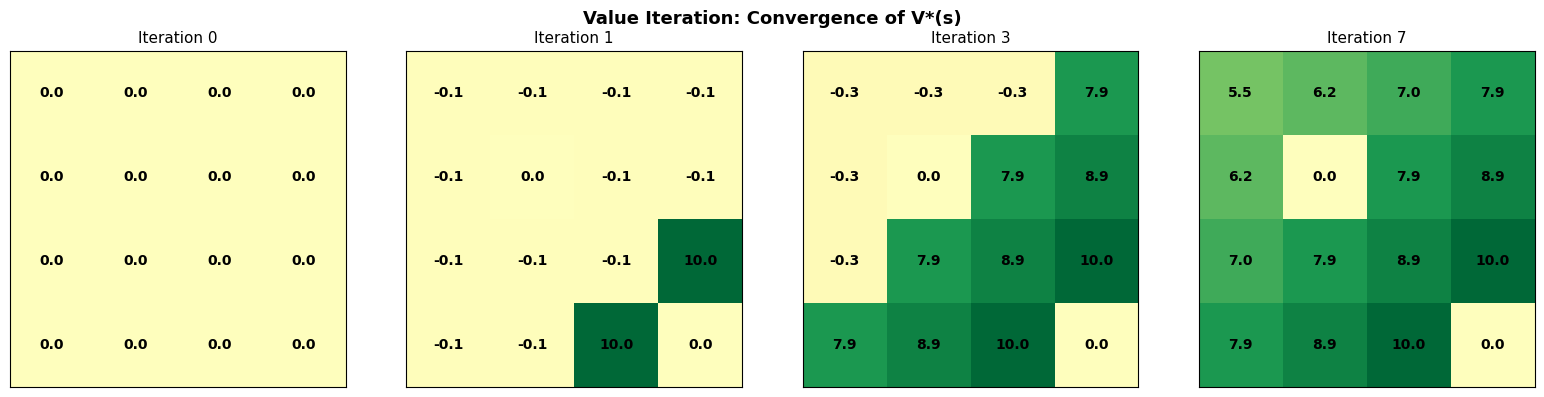

In [ ]:
import numpy as np

grid_size = 4
n_states = grid_size * grid_size
# Actions: up, down, left, right
actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
gamma = 1.0  # undiscounted for this example

# Terminal states: top-left (0,0) and bottom-right (3,3)
terminal_states = [(0, 0), (3, 3)]

def state_to_idx(r, c):
    return r * grid_size + c

def idx_to_state(idx):
    return idx // grid_size, idx % grid_size

# Evaluate a random policy (equal probability for all 4 actions)
# using iterative policy evaluation
V = np.zeros(n_states)
threshold = 1e-6

for iteration in range(1000):
    V_new = np.zeros(n_states)
    for s in range(n_states):
        r, c = idx_to_state(s)
        if (r, c) in terminal_states:
            V_new[s] = 0
            continue
        for dr, dc in actions:
            nr, nc = r + dr, c + dc
            # Stay in place if moving off grid
            if nr < 0 or nr >= grid_size or nc < 0 or nc >= grid_size:
                nr, nc = r, c
            s_next = state_to_idx(nr, nc)
            # Random policy: each action with probability 1/4
            V_new[s] += 0.25 * (-1 + gamma * V[s_next])
    if np.max(np.abs(V_new - V)) < threshold:
        print(f"Converged after {iteration + 1} iterations")
        break
    V = V_new

V_grid = V.reshape(grid_size, grid_size)
print("Value function under random policy:")
print(np.round(V_grid, 1))

![Gridworld value function](figs/rl-gridworld-values.png)

The values are all negative because the agent receives $-1$ at every step under the random policy. States far from both terminal states have the most negative values (the agent wanders for a long time before reaching a terminal state). States near the terminals have values closer to zero.

### The Bellman Optimality Equation

The **optimal value function** $V^*(s)$ is the maximum value achievable from state $s$ under any policy:

$$V^*(s) = \max_a \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma \, V^*(s') \right]$$

The difference from the regular Bellman equation is the $\max_a$ instead of averaging over actions. The optimal policy always picks the best action.

Similarly, the **optimal Q-function**:

$$Q^*(s, a) = \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma \max_{a'} Q^*(s', a') \right]$$

Once we have $Q^*$, the optimal policy is simple: always pick the action with the highest Q-value.

$$\pi^*(s) = \arg\max_a Q^*(s, a)$$

### Question

Look at the gridworld value function above. The cell at (row 1, col 1) has a value of $-18$. Under the random policy, the agent takes each action with probability $1/4$.

If you could choose the action deterministically, which action would you choose in this cell, and why? Would the value of this cell increase or decrease under a better policy?

### Answer

We should move either up or left, since those actions bring us closer to the terminal state at (0, 0). Moving up takes us to (0, 1) with value $-14$, and moving left takes us to (1, 0) with value $-14$. Either is equally good. The value of this cell would increase (become less negative) under a better policy because the agent would reach the terminal state in fewer steps, accumulating fewer $-1$ penalties.

## Q-Learning

Now we get to the core of **model-free** RL. The "model" in model-free refers to the MDP's transition probabilities $P(s' \mid s, a)$ and reward function $R(s, a, s')$. A **model-based** method requires knowing (or learning) these functions explicitly, like we did in the gridworld example above where we used $P$ and $R$ to compute value functions. A **model-free** method doesn't need them. The agent learns directly from experience by interacting with the environment and observing what happens. In many real problems, the transition dynamics are unknown or too complex to specify. **Q-learning** is an algorithm that learns the optimal Q-function directly from interactions with the environment, without needing a model.

### The Q-learning update rule

The agent maintains a table of Q-values, $Q(s, a)$, for every state-action pair. All Q-values are typically initialized to zero (meaning the agent starts with no knowledge about which actions are good). As the agent interacts with the environment, it updates these estimates. After each experience $(s, a, r, s')$, the agent updates:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Let's unpack each part:

* $Q(s, a)$: the current estimate of the value of taking action $a$ in state $s$
* $\alpha \in (0, 1]$: the **learning rate** (how much to update toward the new information)
* $r$: the actual reward received
* $\gamma \max_{a'} Q(s', a')$: the estimated value of the best action from the next state
* $r + \gamma \max_{a'} Q(s', a')$: the **TD target** (temporal difference target), our improved estimate
* $r + \gamma \max_{a'} Q(s', a') - Q(s, a)$: the **TD error**, the difference between our improved estimate and our old estimate

The update moves $Q(s, a)$ a fraction $\alpha$ toward the TD target. This is similar to gradient descent: we take a small step toward a better estimate.

### How does the agent choose actions during learning?

There is a dilemma: the agent needs to take actions to collect experiences and update its Q-values, but it doesn't yet know which actions are good. If the agent always picks the action with the highest current Q-value (called the **greedy** action), it might never try alternatives that could be better. If it always picks randomly, it never uses what it has learned.

A simple solution is the **epsilon-greedy** strategy: with probability $\epsilon$ (a small number like 0.1), the agent picks a random action (**explores**); with probability $1 - \epsilon$, it picks the action with the highest Q-value (**exploits**). We will examine this tradeoff in more detail later, but for now, epsilon-greedy is what makes Q-learning work in practice.

### Q-learning on a cliff-walking gridworld

Let's implement Q-learning on a more interesting gridworld. The agent starts at the bottom-left and must reach the goal at the bottom-right. The bottom row (except start and goal) is a cliff: stepping on it gives a $-100$ reward penalty and sends the agent back to the start, but the episode continues (cliff cells are not terminal states). The only terminal state is the goal. All other moves give $-1$.

![Cliff World setup](figs/rl-cliffworld-setup.png)

In [ ]:
class CliffWorld:
    def __init__(self, rows=4, cols=12):
        self.rows = rows
        self.cols = cols
        self.start = (rows - 1, 0)
        self.goal = (rows - 1, cols - 1)
        # Cliff: bottom row between start and goal
        self.cliff = [(rows - 1, c) for c in range(1, cols - 1)]
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right
        self.action_names = ["↑", "↓", "←", "→"]

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action_idx):
        dr, dc = self.actions[action_idx]
        r, c = self.state
        nr = max(0, min(self.rows - 1, r + dr))
        nc = max(0, min(self.cols - 1, c + dc))
        new_state = (nr, nc)

        if new_state in self.cliff:
            self.state = self.start
            return self.start, -100, False
        elif new_state == self.goal:
            self.state = new_state
            return new_state, -1, True
        else:
            self.state = new_state
            return new_state, -1, False


def q_learning(env, n_episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1):
    """Q-learning with epsilon-greedy exploration."""
    Q = np.zeros((env.rows, env.cols, len(env.actions)))
    episode_rewards = []

    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0

        for step in range(1000):  # max steps per episode
            r, c = state

            # Epsilon-greedy action selection
            if np.random.random() < epsilon:
                action = np.random.randint(len(env.actions))
            else:
                action = np.argmax(Q[r, c])

            next_state, reward, done = env.step(action)
            total_reward += reward
            nr, nc = next_state

            # Q-learning update
            td_target = reward + gamma * np.max(Q[nr, nc])
            td_error = td_target - Q[r, c, action]
            Q[r, c, action] += alpha * td_error

            state = next_state
            if done:
                break

        episode_rewards.append(total_reward)

    return Q, episode_rewards


np.random.seed(42)
env = CliffWorld()
Q, rewards = q_learning(env, n_episodes=500)

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 14.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 13.8 MB/s eta 0:00:0031m15.7 MB/s eta 0:00:01
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.0 MB/s eta 0:00:00 MB/s eta 0:00:01:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


To understand how Q-learning works, let's visualize the Q-values at different stages of training. Each cell shows $\max_a Q(s, a)$, the estimated value of the best action in that state. Initially, all Q-values are zero (the agent knows nothing). As the agent explores, it learns which states are good (close to the goal) and which are bad (close to the cliff).

![Q-value evolution during training](figs/rl-qlearning-evolution.png)

Notice that cliff cells (shown in gray) have no Q-values. This is because the agent never occupies a cliff cell: when it steps onto one, the environment immediately sends it back to the start. Since the Q-learning update only modifies Q-values for states the agent is *in*, cliff cells are never updated.

After just 10 episodes, the agent has started learning: cells near the goal have less negative values (greener), while cells on the left are more negative (the agent wanders longer before reaching the goal). By episode 50, a clear gradient has formed across the grid, pointing the agent toward the goal and away from the cliff. After 500 episodes, the values have converged: the safe path along the top row has the least negative values.

![Q-learning on cliff world](figs/rl-qlearning-curve.png)

The learning curve shows the total reward per episode. Early episodes have very negative rewards (the agent falls off the cliff many times), but it gradually learns the safe path along the top.

![Learned Q-learning policy](figs/rl-qlearning-policy.png)

The learned policy avoids the cliff and takes the optimal path from start (S) to goal (G).

### Question

Look at the Q-learning update rule:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Suppose $Q(s, a) = 5$, the agent receives reward $r = 1$, the next state has $\max_{a'} Q(s', a') = 8$, $\gamma = 0.9$, and $\alpha = 0.1$.

1. What is the TD target?
2. What is the TD error?
3. What is the new value of $Q(s, a)$?
4. If the learning rate $\alpha$ were $1.0$ instead, what would the new Q-value be? Why might this be a bad idea?

### Answer

1. TD target $= r + \gamma \max Q(s', a') = 1 + 0.9 \times 8 = 8.2$
2. TD error $= 8.2 - 5.0 = 3.2$
3. $Q(s, a) = 5.0 + 0.1 \times 3.2 = 5.32$
4. With $\alpha = 1.0$: $Q(s, a) = 5.0 + 1.0 \times 3.2 = 8.2$. This completely replaces the old estimate with the new one. It's a bad idea because a single experience might be noisy (the reward or next state might not be representative). A small $\alpha$ ensures the Q-value is updated gradually, smoothing out noise across many experiences.

## Exploration vs. Exploitation

We briefly introduced epsilon-greedy when discussing Q-learning. Now let's look at the exploration-exploitation tradeoff more carefully. Should the agent **exploit** its current knowledge (pick the best-known action) or **explore** new actions that might lead to even better outcomes?

Consider choosing a restaurant for dinner. You know a good Italian place (exploitation). But the new French restaurant down the street might be amazing (exploration). If you always go to the Italian place, you'll never discover the French place. If you always try new places, you'll waste many dinners on bad food.

### The epsilon-greedy strategy

The simplest approach is **epsilon-greedy**: with probability $\epsilon$, take a random action (explore); with probability $1 - \epsilon$, take the best-known action (exploit).

$$a = \begin{cases} \text{random action} & \text{with probability } \epsilon \\ \arg\max_a Q(s, a) & \text{with probability } 1 - \epsilon \end{cases}$$

![Exploration strategies](figs/rl-exploration.png)

A common strategy is to start with high $\epsilon$ (lots of exploration) and gradually decay it. Early on, the agent doesn't know much, so exploration is valuable. Later, the agent has learned good Q-values and should exploit more.

### Question

Consider an epsilon-greedy policy with $\epsilon = 0.2$ and 4 possible actions. The Q-values are $Q(s, \text{up}) = 10$, $Q(s, \text{down}) = 3$, $Q(s, \text{left}) = 7$, $Q(s, \text{right}) = 5$.

What is the probability of selecting each action?

### Answer

With $\epsilon = 0.2$, each action gets a "floor" probability of $\epsilon / 4 = 0.05$.

The greedy action is "up" ($Q = 10$), which gets an additional $1 - \epsilon = 0.8$.

Probabilities: up $= 0.05 + 0.80 = 0.85$, down $= 0.05$, left $= 0.05$, right $= 0.05$.

Note: even though "left" has the second-highest Q-value, it gets the same probability as "down" under epsilon-greedy. The epsilon-greedy strategy does not distinguish between non-greedy actions.

### Effect of epsilon on Q-learning

To see the impact of $\epsilon$ in practice, let's run Q-learning on the Cliff World with three different values: $\epsilon = 0$ (pure exploitation, no exploration), $\epsilon = 0.1$ (mostly exploit, some exploration), and $\epsilon = 0.5$ (explore half the time). The figure below shows how Q-values evolve during training and the final learned policy for each.

![Effect of epsilon on Q-learning](figs/rl-epsilon-comparison.png)

With $\epsilon = 0$ (pure greedy), the agent gets stuck exploiting its initial (zero) Q-values. It only updates states along the path it happens to take first and may fail to discover the optimal route. With $\epsilon = 0.1$, the agent explores enough to learn good Q-values across the grid while mostly exploiting what it has learned. With $\epsilon = 0.5$, the agent explores heavily, which helps it discover the full state space, but the Q-values are noisier because it takes random actions so often. The final policies show that moderate exploration ($\epsilon = 0.1$) strikes the best balance.

## Policy Gradient Methods

Q-learning learns a value function and derives a policy from it. **Policy gradient methods** take a completely different approach: they learn the policy directly.

Instead of a Q-table, we parameterize the policy with a set of parameters $\theta$:

$$\pi_\theta(a \mid s) = P(A_t = a \mid S_t = s; \theta)$$

The goal is to find $\theta$ that maximizes the expected return:

$$J(\theta) = \mathbb{E}_{\pi_\theta}[G_0]$$

### Why learn the policy directly?

1. **Continuous action spaces**: Q-learning requires computing $\max_a Q(s, a)$, which is easy when there are a few discrete actions, but intractable for continuous actions (e.g., controlling a robot arm with joint angles).
2. **Stochastic policies**: Sometimes the optimal policy is stochastic. Policy gradient methods can naturally represent and learn stochastic policies.
3. **Scalability**: With function approximation (neural networks), policy gradient methods can handle very large state spaces.

### The policy gradient theorem

To optimize $J(\theta)$, we need its gradient $\nabla_\theta J(\theta)$. The challenge is that $J(\theta)$ depends on $\theta$ in a complex way: changing $\theta$ changes the policy, which changes the actions taken, which changes the states visited, which changes the rewards received. Let's derive the gradient step by step for a single-step episode to build intuition, then state the general result.

**Single-step case.** Suppose the episode lasts exactly one step. The agent is in state $s$, takes action $a$, receives reward $R(s, a)$, and the episode ends. The objective is:

$$J(\theta) = \sum_a \pi_\theta(a \mid s) \, R(s, a)$$

Taking the gradient with respect to $\theta$:

$$\nabla_\theta J(\theta) = \sum_a \nabla_\theta \pi_\theta(a \mid s) \, R(s, a)$$

Now we use the **log-derivative trick** (also called the REINFORCE trick or score function trick). For any function $f(\theta)$:

$$\nabla_\theta f(\theta) = f(\theta) \, \nabla_\theta \log f(\theta)$$

This follows from the chain rule: $\nabla_\theta \log f = \frac{\nabla_\theta f}{f}$, so $\nabla_\theta f = f \cdot \nabla_\theta \log f$.

Applying this to $\pi_\theta(a \mid s)$:

$$\nabla_\theta \pi_\theta(a \mid s) = \pi_\theta(a \mid s) \, \nabla_\theta \log \pi_\theta(a \mid s)$$

Substituting back:

$$\nabla_\theta J(\theta) = \sum_a \pi_\theta(a \mid s) \, \nabla_\theta \log \pi_\theta(a \mid s) \, R(s, a)$$

This sum over actions weighted by $\pi_\theta(a \mid s)$ is just an expectation:

$$\nabla_\theta J(\theta) = \mathbb{E}_{a \sim \pi_\theta}\left[ \nabla_\theta \log \pi_\theta(a \mid s) \, R(s, a) \right]$$

This is remarkable: we turned a gradient of a sum into an expectation that we can estimate by sampling actions from our policy. We never need to differentiate through the environment or know the reward function explicitly.

**Multi-step case.** For a full episode of length $T$, the derivation extends to sum over all time steps, replacing the single reward $R(s, a)$ with the return $G_t$ from that time step onward. The full **policy gradient theorem** states:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[ \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(A_t \mid S_t) \, G_t \right]$$

The intuition: if action $A_t$ led to a high return $G_t$, increase the probability of taking that action. If it led to a low return, decrease the probability. The magnitude of the update is proportional to the return.

This is the "try stuff, see what works, do more of what works" principle, made mathematically precise.

### The REINFORCE algorithm

REINFORCE is the simplest policy gradient algorithm:

1. Run the policy $\pi_\theta$ for a complete episode, recording states, actions, and rewards
2. Compute the return $G_t$ for each time step
3. Update the parameters: $\theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(A_t \mid S_t) \, G_t$

The policy network outputs a probability distribution over actions. We use PyTorch's `Categorical` distribution to sample from it. A **categorical distribution** is simply a distribution over a finite set of outcomes with specified probabilities (e.g., action "left" with probability 0.3, "right" with probability 0.7). It generalizes the Bernoulli distribution to more than two outcomes.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical


class PolicyNetwork(nn.Module):
    """A simple policy network for discrete actions."""

    def __init__(self, n_states, n_actions, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
            nn.Softmax(dim=-1),
        )

    def forward(self, state):
        return self.net(state)

    def select_action(self, state):
        state_tensor = torch.FloatTensor(state)
        probs = self.forward(state_tensor)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)


def reinforce(env, policy, optimizer, n_episodes=1000, gamma=0.99):
    """REINFORCE algorithm."""
    episode_rewards = []

    for episode in range(n_episodes):
        state = env.reset()
        log_probs = []
        rewards = []

        # Collect one episode
        for step in range(200):
            action, log_prob = policy.select_action(state)
            next_state, reward, done = env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state
            if done:
                break

        episode_rewards.append(sum(rewards))

        # Compute returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        # Normalize returns for stability
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Policy gradient update
        loss = 0
        for log_prob, G_t in zip(log_probs, returns):
            loss -= log_prob * G_t

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return episode_rewards

DQN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Parameters: 4,610


The core of REINFORCE is these three lines:

```py
for log_prob, G_t in zip(log_probs, returns):
    loss -= log_prob * G_t
```

For each time step, we add $-\log \pi_\theta(a_t \mid s_t) \times G_t$ to the loss. Taking the gradient of this loss and doing gradient descent is equivalent to the policy gradient update. Actions followed by high returns have their probabilities increased; actions followed by low returns have their probabilities decreased.

### Question

In the REINFORCE algorithm, we normalize the returns:

```py
returns = (returns - returns.mean()) / (returns.std() + 1e-8)
```

Why is this normalization important? What would happen without it?

### Answer

Without normalization, if all returns are positive (which happens in many environments), the gradient update would increase the probability of all actions, just by different amounts. This works in theory but leads to high variance in practice because the gradient magnitudes depend on the absolute scale of returns.

Normalization centers the returns around zero: actions with above-average returns get their probabilities increased, and below-average actions get decreased. This reduces variance and stabilizes training. The $10^{-8}$ prevents division by zero when all returns are the same.

This is an instance of the **baseline** technique: subtracting the mean return is the simplest baseline. More advanced methods use a learned value function as the baseline, which we will discuss shortly.

## Deep Reinforcement Learning

When the state space is very large (e.g., raw pixels of an Atari game), we can't store a Q-table for every state. Instead, we approximate $Q(s, a)$ with a neural network. This is still a **value-based** method (the network learns Q-values, and the policy is derived as $\arg\max_a Q(s, a)$). This is the idea behind **Deep Q-Networks (DQN)**, which was the breakthrough that enabled RL agents to play Atari games at superhuman level.

### From Q-table to Q-network

In tabular Q-learning, we store Q-values in a table. With a neural network, we instead train a network $Q_\theta(s, a)$ parameterized by weights $\theta$:

```
Q-table:                      Q-network:
┌───────┬──────┬──────┐       ┌─────────┐
│ State │ Left │Right │       │  State  │──┐
├───────┼──────┼──────┤       └─────────┘  │    ┌─────────────┐
│  s1   │ 1.2  │ 3.4  │  →   Neural Net   │───→│ Q(s, left)  │
│  s2   │ 0.5  │ 2.1  │       (weights θ)  │───→│ Q(s, right) │
│  ...  │ ...  │ ...  │                    │    └─────────────┘
└───────┴──────┴──────┘       └────────────┘
```

The network takes a state as input and outputs Q-values for all actions simultaneously.

### Key DQN innovations

Training a neural network with Q-learning directly is unstable. DQN introduced two techniques to stabilize training:

1. **Experience replay**: Store past experiences $(s, a, r, s')$ in a buffer and sample random mini-batches for training. This breaks the correlation between consecutive experiences and improves data efficiency.

2. **Target network**: Use a separate, slowly-updated copy of the network to compute TD targets. This prevents the "moving target" problem where updates to the Q-network immediately change the TD targets.

```py
# Illustration: experience replay buffer
from collections import deque
import random

class ReplayBuffer:
    """Store and sample past experiences."""

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))

    def __len__(self):
        return len(self.buffer)


# Example usage
buffer = ReplayBuffer(capacity=5000)

# During training, store every experience
# buffer.push(state, action, reward, next_state, done)

# Then sample mini-batches for training
# states, actions, rewards, next_states, dones = buffer.sample(batch_size=32)
```

### Comparison: value-based vs. policy-based methods

An important distinction is whether an algorithm is **off-policy** or **on-policy**. An **off-policy** method (like Q-learning) can learn from data collected by any policy, including old experiences stored in a replay buffer. An **on-policy** method (like REINFORCE) can only learn from data collected by the current policy, so old data must be discarded after each update. Off-policy methods are more sample-efficient but can be less stable.

| Feature | Q-learning / DQN | Policy Gradient / REINFORCE |
|---------|-------------------|-----------------------------|
| Learns | Value function $Q(s, a)$ | Policy $\pi_\theta(a \mid s)$ directly |
| Action space | Discrete only | Discrete or continuous |
| Exploration | Epsilon-greedy (separate) | Built into stochastic policy |
| Sample efficiency | More efficient (off-policy: can learn from old data) | Less efficient (on-policy: must use data from current policy) |
| Stability | Can diverge with function approx. | More stable gradient updates |
| Variance | Lower variance | Higher variance |

Modern methods like **Actor-Critic** combine both: a "critic" learns the value function and an "actor" learns the policy. The critic's value estimates reduce the variance of the policy gradient, giving us the best of both worlds.

## Applications in Healthcare and Biomedical Research

RL has growing applications in biostatistics and healthcare, which are particularly relevant for this course:

**Dynamic treatment regimes (DTRs).**  In many chronic diseases (cancer, diabetes, HIV), treatment decisions are made sequentially over time. The optimal treatment at each stage may depend on the patient's evolving condition and response to previous treatments. RL provides a natural framework for learning optimal DTRs.

* **States**: Patient health measurements (lab values, symptoms, imaging)
* **Actions**: Treatment options (drug choice, dosage, radiation schedule)
* **Rewards**: Patient outcomes (survival time, quality of life, disease progression)

The following simulation compares a fixed-dose insulin policy with an adaptive (RL-like) policy that adjusts dosage based on the patient's current glucose level:

![Healthcare application: glucose management](figs/rl-healthcare.png)

The fixed-dose policy overshoots for many patients, driving glucose dangerously low. The adaptive policy adjusts the dose based on the current state, keeping glucose closer to the target. An RL agent could learn such an adaptive policy from patient data.

**Other biomedical applications include**:

* **Sepsis treatment**: RL agents that recommend fluid and vasopressor dosing in ICUs, where delayed and sparse rewards (patient survival) make this a challenging RL problem
* **Radiation therapy planning**: Optimizing beam angles and dosages across multiple treatment sessions
* **Clinical trial design**: Adaptive trial designs that learn which patients benefit from which treatments during the trial itself
* **Drug discovery**: RL agents that learn to construct molecular structures with desired properties

### Question

In the glucose management example above, we used a simple rule-based adaptive policy (dose proportional to the deviation from target). How would you frame this as an RL problem? Specifically:

1. What would the state space include?
2. What would the action space be?
3. How would you define the reward function to encourage keeping glucose in the normal range (70-180 mg/dL) while penalizing dangerous levels?

### Answer

1. **State space**: Current glucose level, recent glucose trend (rising/falling), time of day, whether the patient has eaten recently, insulin sensitivity estimate, and patient demographics.

2. **Action space**: Discrete insulin doses (e.g., 0, 2, 5, 8, 10, 15 units) or a continuous dose level.

3. **Reward function**: One reasonable design:
    * $R = 0$ if glucose is in the target range (80-120 mg/dL)
    * $R = -1$ if glucose is in the acceptable range (70-180 mg/dL) but outside the target
    * $R = -10$ if glucose is mildly out of range (60-70 or 180-250 mg/dL)
    * $R = -100$ if glucose is dangerously out of range (< 60 or > 250 mg/dL)

The asymmetric penalty (hypoglycemia is more dangerous than hyperglycemia) should be reflected in the reward function. Reward engineering is one of the hardest parts of applying RL in practice.

## Putting It All Together: Training a CartPole Agent

Let's apply what we've learned to a classic RL benchmark: **CartPole**. A pole is attached to a cart on a frictionless track. The agent must keep the pole balanced by pushing the cart left or right.

* **State**: cart position, cart velocity, pole angle, pole angular velocity (4 continuous values)
* **Actions**: push left (0) or push right (1)
* **Reward**: $+1$ for each time step the pole stays upright
* **Goal**: keep the pole balanced for 500 steps

![CartPole environment](figs/rl-cartpole-setup.png)

The episode ends (pole "falls") if the pole angle exceeds $\pm 12°$ or the cart moves off-screen. Unlike the cliff world where we used a Q-table, the state space here is continuous (infinite possible states), so we cannot store a Q-value for every state. Instead, we use the REINFORCE algorithm with a neural network policy.

**Model architecture.** The policy network takes the 4-dimensional state as input and outputs a probability distribution over the 2 actions. We use a single hidden layer with 128 neurons and ReLU activation, followed by a Softmax output layer. This is a small network (4 $\times$ 128 + 128 $\times$ 2 = 768 weights plus biases), which is sufficient for this simple task.

**Training details.** We train for 1000 episodes using the Adam optimizer with learning rate 0.002 and discount factor $\gamma = 0.99$. Each episode, the agent collects a full trajectory (sequence of states, actions, and rewards), computes the discounted return $G_t$ for each time step, normalizes the returns (baseline subtraction), and updates the policy parameters using the REINFORCE gradient. The training loop processes one episode at a time (no mini-batching across episodes).

Episode 100, Avg reward (last 100): 11.7
Episode 200, Avg reward (last 100): 11.6
Episode 300, Avg reward (last 100): 10.2
Episode 400, Avg reward (last 100): 9.7
Episode 500, Avg reward (last 100): 9.6


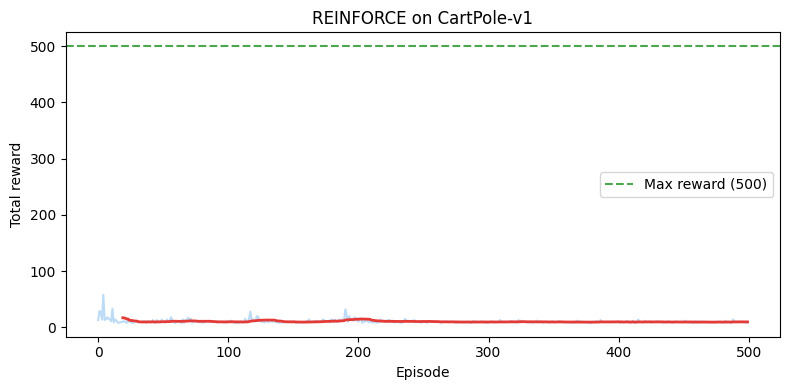

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Create the CartPole environment
cart_env = gym.make("CartPole-v1")

class CartPolePolicy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.net(x)

    def select_action(self, state):
        state_t = torch.FloatTensor(state)
        probs = self.forward(state_t)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)


def train_cartpole(n_episodes=1000, gamma=0.99, lr=0.002):
    policy = CartPolePolicy()
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    episode_rewards = []

    for episode in range(n_episodes):
        state, _ = cart_env.reset(seed=episode % 100)
        log_probs = []
        rewards = []

        for t in range(500):
            action, log_prob = policy.select_action(state)
            state, reward, terminated, truncated, _ = cart_env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            if terminated or truncated:
                break

        episode_rewards.append(sum(rewards))

        # Compute discounted returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # REINFORCE update
        loss = sum(-lp * Gt for lp, Gt in zip(log_probs, returns))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return episode_rewards


torch.manual_seed(0)
np.random.seed(0)
rewards_history = train_cartpole()

![REINFORCE on CartPole](figs/rl-cartpole.png)

The agent starts with random actions (averaging around 20-40 steps) and gradually learns to balance the pole for hundreds of steps. CartPole-v1 is considered "solved" when the average reward exceeds 475 over 100 consecutive episodes.

Here is what the policy looks like at different stages of training. Early on, the agent drops the pole almost immediately. As training progresses, it learns to make corrective pushes and eventually balances the pole for the full episode:

![CartPole after 10 episodes](figs/rl-cartpole-ep0010.gif)

![CartPole after 100 episodes](figs/rl-cartpole-ep0100.gif)

![CartPole after 1000 episodes](figs/rl-cartpole-ep1000.gif)

### Question

The CartPole policy network has the architecture: `Linear(4, 128) → ReLU → Linear(128, 2) → Softmax`.

1. What do the 4 input features represent?
2. Why does the output layer have 2 neurons?
3. Why do we use Softmax (instead of, say, ReLU) in the final layer?
4. How is this network different from a classification network you might see in supervised learning?

### Answer

1. The 4 input features are: cart position, cart velocity, pole angle, and pole angular velocity.
2. The 2 output neurons correspond to the 2 possible actions: push left and push right.
3. Softmax converts the outputs to probabilities that sum to 1. This is necessary because the output represents a probability distribution over actions, $\pi_\theta(a \mid s)$, from which we sample actions.
4. Architecturally, it looks identical to a binary classifier. The difference is in training: a classifier trains on labeled examples (cross-entropy loss), while a policy network trains using the policy gradient (actions weighted by returns). There are no "correct labels." The network discovers good actions through trial and error.

## Summary

Reinforcement learning provides a framework for learning sequential decision-making through trial and error. Here are the key concepts we covered:

| Concept | Description |
|---------|-------------|
| Agent, environment, state, action, reward | The basic building blocks of RL |
| MDP | Formal framework: $(S, A, P, R, \gamma)$ |
| Return $G_t$ | Discounted cumulative future reward |
| Policy $\pi$ | Strategy mapping states to actions |
| Value function $V^\pi(s)$ | Expected return from state $s$ under policy $\pi$ |
| Q-function $Q^\pi(s, a)$ | Expected return for taking action $a$ in state $s$ |
| Bellman equation | Recursive relationship between state values |
| Q-learning | Model-free algorithm that learns $Q^*$ from experience |
| Epsilon-greedy | Simple exploration strategy |
| Policy gradient / REINFORCE | Directly optimize the policy using gradient ascent |
| DQN | Q-learning with neural network function approximation |

## Recommended Resources

* [Sutton & Barto, *Reinforcement Learning: An Introduction*](http://incompleteideas.net/book/the-book.html) - The definitive textbook, freely available online
* [OpenAI Spinning Up](https://spinningup.openai.com) - Practical introduction to deep RL with code
* [David Silver's RL Course (UCL/DeepMind)](https://www.davidsilver.uk/teaching/) - Excellent video lectures
* [Lilian Weng's Policy Gradient Blog Post](https://lilianweng.github.io/posts/2018-04-08-policy-gradient/) - Clear derivations with code